# GRID Lip Reading — Training

Обучение LipReadingTransformerMBConv на датасете GRID.

- 1 спикер (s1), 1000 видео, 52 слова
- Word-level alignments (точные таймстампы)
- 25 fps, 75 кадров/видео, 360×288 → crop губ 96×64
- Простой word→id словарь (без BPE)

In [1]:
# %pip install mediapipe
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import cv2
import numpy as np
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

from model_mbconv import LipReadingTransformerMBConv, load_config

## Параметры

In [2]:
# ── Пути ──
GRID_PATH       = Path("D:/GitHub/Datasets/GRID/data")
VIDEO_PATH      = GRID_PATH / "s1"
ALIGN_PATH      = GRID_PATH / "alignments" / "s1"
CONFIG_PATH     = Path("configs/model_config_grid.json")

# ── Конфиг модели ──
MODEL_CONFIG = load_config(CONFIG_PATH)
VOCAB_SIZE   = MODEL_CONFIG["vocab_size"]
MAX_FRAMES   = MODEL_CONFIG["max_frames"]
MAX_TOKENS   = MODEL_CONFIG["max_tokens"]

# ── Спец-токены ──
PAD_TOKEN_ID = 0
BOS_TOKEN_ID = 1
EOS_TOKEN_ID = 2
WORD_OFFSET  = 3   # слова начинаются с id=3

# ── Обучение ──
BATCH_SIZE    = 16
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 30

# ── Сплиты (из 1000 видео) ──
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Config: d_model={MODEL_CONFIG['d_model']}, vocab={VOCAB_SIZE}, "
      f"max_frames={MAX_FRAMES}, max_tokens={MAX_TOKENS}")

Device: cuda
Config: d_model=48, vocab=55, max_frames=75, max_tokens=8


## Словарь GRID (word → id)

In [3]:
from collections import Counter

# ── Построение словаря word -> id ──
word_counts = Counter()
for align_file in ALIGN_PATH.glob('*.align'):
    for line in align_file.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2] not in ('sil', 'sp'):
            word_counts[parts[2]] += 1

words_sorted = sorted(word_counts.keys())
word2id = {w: i + WORD_OFFSET for i, w in enumerate(words_sorted)}
id2word = {v: k for k, v in word2id.items()}
id2word[PAD_TOKEN_ID] = '<pad>'
id2word[BOS_TOKEN_ID] = '<bos>'
id2word[EOS_TOKEN_ID] = '<eos>'

print(f'Unique words: {len(word2id)}')
print(f'Vocab size (with special tokens): {len(word2id) + 3}')
print()

# ── Кэш кадров губ ──
CACHE_DIR = Path('D:/GitHub/Datasets/GRID/cache_s1')
TARGET_H, TARGET_W = 64, 96

if not CACHE_DIR.exists() or len(list(CACHE_DIR.glob('*.npy'))) == 0:
    print('Cache not found! Run first:')
    print('  python preprocess_grid.py --method fixed')
else:
    cached = list(CACHE_DIR.glob('*.npy'))
    print(f'Cache: {len(cached)} files in {CACHE_DIR}')
    sample = np.load(cached[0])
    print(f'Example: {cached[0].name}, shape={sample.shape}')


Unique words: 51
Vocab size (with special tokens): 54

Cache: 1000 files in D:\GitHub\Datasets\GRID\cache_s1
Example: bbaf2n.npy, shape=(75, 64, 96, 3)


## Dataset GRID (из кэша)

In [4]:
class GRIDDataset(Dataset):
    def __init__(self, video_names, align_path, word2id, cache_dir,
                 max_frames=MAX_FRAMES, max_tokens=MAX_TOKENS, augment=False):
        self.video_names = video_names
        self.align_path = Path(align_path)
        self.word2id = word2id
        self.cache_dir = Path(cache_dir)
        self.max_frames = max_frames
        self.max_tokens = max_tokens
        self.augment = augment

    def __len__(self):
        return len(self.video_names)

    def _parse_alignment(self, name):
        align_file = self.align_path / f'{name}.align'
        words = []
        for line in align_file.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 3 and parts[2] not in ('sil', 'sp'):
                words.append(parts[2])
        return words

    def __getitem__(self, idx):
        name = self.video_names[idx]
        cache_file = self.cache_dir / f'{name}.npy'
        if cache_file.exists():
            raw = np.load(cache_file)
        else:
            raw = np.zeros((1, TARGET_H, TARGET_W, 3), dtype=np.uint8)

        frames = np.transpose(raw, (0, 3, 1, 2)).astype(np.float32) / 255.0
        n_real = frames.shape[0]
        if n_real > self.max_frames:
            frames = frames[:self.max_frames]
            n_real = self.max_frames
        elif n_real < self.max_frames:
            pad = np.zeros((self.max_frames - n_real, *frames.shape[1:]), dtype=np.float32)
            frames = np.concatenate([frames, pad], axis=0)

        if self.augment:
            if np.random.rand() > 0.5:
                frames = np.clip(frames * np.float32(np.random.uniform(0.7, 1.3)), 0, 1)
            if np.random.rand() > 0.5:
                frames = np.clip((frames - 0.5) * np.float32(np.random.uniform(0.8, 1.2)) + 0.5, 0, 1)

        src_padding_mask = [False] * n_real + [True] * (self.max_frames - n_real)

        words = self._parse_alignment(name)
        word_ids = [self.word2id.get(w, PAD_TOKEN_ID) for w in words]
        content = word_ids[:self.max_tokens - 1]
        decoder_input = [BOS_TOKEN_ID] + content
        target        = content + [EOS_TOKEN_ID]
        dec_len = len(decoder_input)
        decoder_input += [PAD_TOKEN_ID] * (self.max_tokens - dec_len)
        target        += [PAD_TOKEN_ID] * (self.max_tokens - len(target))
        tgt_padding_mask = [False] * dec_len + [True] * (self.max_tokens - dec_len)

        return {
            'frames':           torch.tensor(frames, dtype=torch.float32),
            'src_padding_mask': torch.tensor(src_padding_mask, dtype=torch.bool),
            'decoder_input':    torch.tensor(decoder_input, dtype=torch.long),
            'target':           torch.tensor(target, dtype=torch.long),
            'tgt_padding_mask': torch.tensor(tgt_padding_mask, dtype=torch.bool),
        }


## Создание сплитов и загрузчиков

In [5]:
all_names = sorted([
    f.stem for f in CACHE_DIR.glob('*.npy')
    if (ALIGN_PATH / f'{f.stem}.align').exists()
])
print(f'Videos with cache+alignment: {len(all_names)}')

np.random.seed(42)
indices = np.random.permutation(len(all_names))
n_train = int(len(all_names) * TRAIN_RATIO)
n_val   = int(len(all_names) * VAL_RATIO)

train_names = [all_names[i] for i in indices[:n_train]]
val_names   = [all_names[i] for i in indices[n_train:n_train + n_val]]
test_names  = [all_names[i] for i in indices[n_train + n_val:]]

print(f'Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}')

train_dataset = GRIDDataset(train_names, ALIGN_PATH, word2id, CACHE_DIR, augment=True)
val_dataset   = GRIDDataset(val_names,   ALIGN_PATH, word2id, CACHE_DIR, augment=False)
test_dataset  = GRIDDataset(test_names,  ALIGN_PATH, word2id, CACHE_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

batch = next(iter(train_loader))
print(f'frames:        {batch["frames"].shape}')
print(f'decoder_input: {batch["decoder_input"].shape}')
print(f'target:        {batch["target"].shape}')


Videos with cache+alignment: 1000
Train: 800, Val: 100, Test: 100
frames:        torch.Size([16, 75, 3, 64, 96])
decoder_input: torch.Size([16, 8])
target:        torch.Size([16, 8])


## Модель, оптимизатор, loss

In [6]:
model = LipReadingTransformerMBConv(MODEL_CONFIG).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID)

total_params = sum(p.numel() for p in model.parameters())
print(f"Параметры: {total_params:,}")
print(f"  (с vocab=55 embedding+fc_out значительно меньше, чем vocab=1200)")

Параметры: 99,329
  (с vocab=55 embedding+fc_out значительно меньше, чем vocab=1200)


## Функции обучения

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_tokens = 0, 0, 0

    for batch in loader:
        frames    = batch["frames"].to(device)
        src_mask  = batch["src_padding_mask"].to(device)
        dec_input = batch["decoder_input"].to(device)
        target    = batch["target"].to(device)
        tgt_mask  = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_mask,
                       src_padding_mask=src_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)
        mask = target != PAD_TOKEN_ID
        total_correct += (logits.argmax(-1)[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    return total_loss / len(loader.dataset), total_correct / total_tokens


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_tokens = 0, 0, 0

    for batch in loader:
        frames    = batch["frames"].to(device)
        src_mask  = batch["src_padding_mask"].to(device)
        dec_input = batch["decoder_input"].to(device)
        target    = batch["target"].to(device)
        tgt_mask  = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_mask,
                       src_padding_mask=src_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        total_loss += loss.item() * frames.size(0)
        mask = target != PAD_TOKEN_ID
        total_correct += (logits.argmax(-1)[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    return total_loss / len(loader.dataset), total_correct / total_tokens

## Цикл обучения

In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_model_state = None
patience_counter = 0

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Training"):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, "best_model_grid.pt")
        patience_counter = 0
        marker = " *  (saved)"
    else:
        patience_counter += 1
        marker = f" (patience {patience_counter}/{PATIENCE})"

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:3d} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.6f} | "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.6f} | "
        f"lr={lr:.2e}{marker}"
    )

    if patience_counter >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}")
        break

print(f"Обучение завершено. best val_acc={best_val_acc:.6f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ..\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._native_multi_head_attenti

Epoch   1 | train_loss=3.5357  train_acc=0.150179 | val_loss=2.8938  val_acc=0.270000 | lr=1.00e-03 *  (saved)
Epoch   2 | train_loss=2.7990  train_acc=0.257679 | val_loss=2.1934  val_acc=0.337143 | lr=9.99e-04 *  (saved)
Epoch   3 | train_loss=2.2500  train_acc=0.302500 | val_loss=1.8180  val_acc=0.340000 | lr=9.98e-04 *  (saved)
Epoch   4 | train_loss=1.9302  train_acc=0.318929 | val_loss=1.6286  val_acc=0.320000 | lr=9.96e-04 (patience 1/30)
Epoch   5 | train_loss=1.7599  train_acc=0.329286 | val_loss=1.5569  val_acc=0.344286 | lr=9.94e-04 *  (saved)
Epoch   6 | train_loss=1.6687  train_acc=0.338036 | val_loss=1.5339  val_acc=0.324286 | lr=9.91e-04 (patience 1/30)
Epoch   7 | train_loss=1.6192  train_acc=0.341607 | val_loss=1.5191  val_acc=0.317143 | lr=9.88e-04 (patience 2/30)
Epoch   8 | train_loss=1.5958  train_acc=0.346250 | val_loss=1.5241  val_acc=0.314286 | lr=9.84e-04 (patience 3/30)
Epoch   9 | train_loss=1.5766  train_acc=0.342321 | val_loss=1.5135  val_acc=0.332857 | lr=9

## Графики

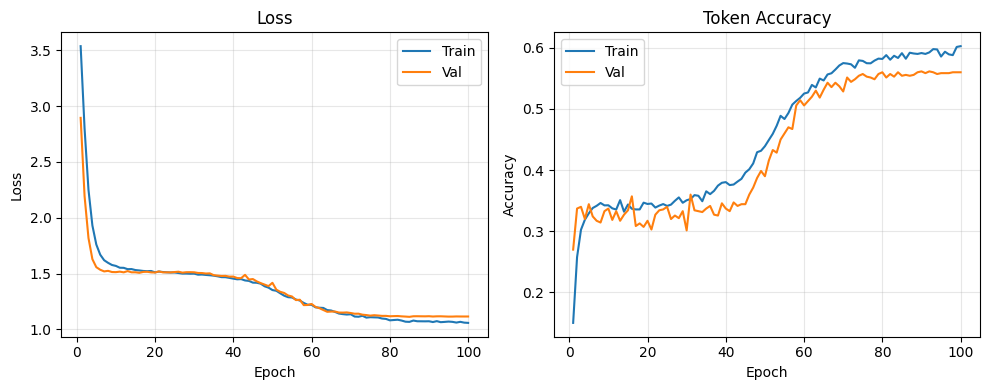

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"grid_training_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150)
plt.show()

## Resume: дообучение с лучшей модели

CosineAnnealing исчерпан (LR→1e-5). Перезапускаем с LR=3e-4.
Разрыв train/val всего 0.04 — модель ещё не переобучена.

In [12]:
# ── Параметры resume ──
RESUME_LR     = 3e-4
RESUME_EPOCHS = 100
RESUME_PATIENCE = 30

# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model_grid.pt', map_location=DEVICE))
print(f'Loaded best model (val_acc={best_val_acc:.6f})')

# Свежий optimizer + scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=RESUME_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=RESUME_EPOCHS, eta_min=1e-5)

print(f'Resume: LR={RESUME_LR}, epochs={RESUME_EPOCHS}')

history_r = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_r = 0.0
best_state_r = None
patience_r = 0

for epoch in tqdm(range(1, RESUME_EPOCHS + 1), desc='Resume'):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history_r['train_loss'].append(train_loss)
    history_r['val_loss'].append(val_loss)
    history_r['train_acc'].append(train_acc)
    history_r['val_acc'].append(val_acc)

    if val_acc > best_val_acc_r:
        best_val_acc_r = val_acc
        best_state_r = copy.deepcopy(model.state_dict())
        torch.save(best_state_r, 'best_model_grid.pt')
        patience_r = 0
        marker = ' *  (saved)'
    else:
        patience_r += 1
        marker = f' (patience {patience_r}/{RESUME_PATIENCE})'

    lr = optimizer.param_groups[0]['lr']
    print(
        f'R-Epoch {epoch:3d} | '
        f'train_loss={train_loss:.4f}  train_acc={train_acc:.6f} | '
        f'val_loss={val_loss:.4f}  val_acc={val_acc:.6f} | '
        f'lr={lr:.2e}{marker}'
    )

    if patience_r >= RESUME_PATIENCE:
        print(f'Early stopping at R-Epoch {epoch}')
        break

print(f'Resume done. Best val_acc: {best_val_acc_r:.6f}')


Loaded best model (val_acc=0.561429)
Resume: LR=0.0003, epochs=100


Resume:   0%|          | 0/100 [00:00<?, ?it/s]

R-Epoch   1 | train_loss=1.0793  train_acc=0.584464 | val_loss=1.1218  val_acc=0.565714 | lr=3.00e-04 *  (saved)
R-Epoch   2 | train_loss=1.0765  train_acc=0.583036 | val_loss=1.1281  val_acc=0.564286 | lr=3.00e-04 (patience 1/30)
R-Epoch   3 | train_loss=1.0741  train_acc=0.582143 | val_loss=1.1378  val_acc=0.557143 | lr=2.99e-04 (patience 2/30)
R-Epoch   4 | train_loss=1.0715  train_acc=0.589643 | val_loss=1.1289  val_acc=0.544286 | lr=2.99e-04 (patience 3/30)
R-Epoch   5 | train_loss=1.0703  train_acc=0.586786 | val_loss=1.1289  val_acc=0.558571 | lr=2.98e-04 (patience 4/30)
R-Epoch   6 | train_loss=1.0618  train_acc=0.597500 | val_loss=1.1282  val_acc=0.564286 | lr=2.97e-04 (patience 5/30)
R-Epoch   7 | train_loss=1.0564  train_acc=0.595179 | val_loss=1.1297  val_acc=0.554286 | lr=2.97e-04 (patience 6/30)
R-Epoch   8 | train_loss=1.0630  train_acc=0.582321 | val_loss=1.1385  val_acc=0.552857 | lr=2.95e-04 (patience 7/30)
R-Epoch   9 | train_loss=1.0477  train_acc=0.605536 | val_los

## Тест и инференс

In [13]:
model.load_state_dict(torch.load("best_model_grid.pt", map_location=DEVICE))
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test token accuracy: {test_acc:.4f}")

Test loss: 1.1253
Test token accuracy: 0.5900


In [14]:
@torch.no_grad()
def greedy_decode(model, frames_tensor, max_len=MAX_TOKENS, device=DEVICE):
    model.eval()
    video = frames_tensor.unsqueeze(0).to(device)
    memory = model.encoder(video)
    if isinstance(memory, tuple):
        memory = memory[0]

    generated = [BOS_TOKEN_ID]
    for _ in range(max_len - 1):
        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model.decoder(tgt, memory)
        next_token = logits[0, -1].argmax().item()
        generated.append(next_token)
        if next_token == EOS_TOKEN_ID:
            break

    return [t for t in generated if t not in (BOS_TOKEN_ID, EOS_TOKEN_ID, PAD_TOKEN_ID)]


# Примеры инференса
print("=== Greedy decode на тестовых сэмплах ===")
for i in range(min(10, len(test_dataset))):
    sample = test_dataset[i]
    pred_ids = greedy_decode(model, sample["frames"])
    pred_words = [id2word.get(t, "?") for t in pred_ids]

    gt_ids = [t for t in sample["target"].tolist() if t not in (EOS_TOKEN_ID, PAD_TOKEN_ID)]
    gt_words = [id2word.get(t, "?") for t in gt_ids]

    print(f"[{i}] Pred: {' '.join(pred_words):30s} | GT: {' '.join(gt_words)}")

=== Greedy decode на тестовых сэмплах ===
[0] Pred: set red at i six please        | GT: set green at i nine again
[1] Pred: set green with j nine again    | GT: set green with j six please
[2] Pred: lay blue with l four now       | GT: lay blue by y three soon
[3] Pred: bin white by g nine soon       | GT: bin white by g nine soon
[4] Pred: set white at t three soon      | GT: bin red in z seven soon
[5] Pred: place white at j seven again   | GT: place green at e zero please
[6] Pred: place white with x two please  | GT: place white with e two please
[7] Pred: set red at v nine again        | GT: lay red in k five again
[8] Pred: place red by p eight please    | GT: place white by k three again
[9] Pred: lay green with l nine again    | GT: lay white with f eight please
